In [35]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, RocCurveDisplay
)

# Global seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13})

print("✓ All imports successful.")



✓ All imports successful.


In [36]:
df = pd.read_csv('data_cleaned(1).csv')  # adjust path if needed

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Shape: (100000, 16)

Columns: ['college_tier', 'placement_status', 'salary_package_lpa', 'salary_available', 'tech_skill', 'soft_skill', 'practical_skill', 'cgpa_scaled', 'backlogs_scaled', 'academic_points', 'branch_CSE', 'branch_Chemical', 'branch_ECE', 'branch_EE', 'branch_IT', 'branch_ME']


,college_tier,placement_status,salary_package_lpa,salary_available,tech_skill,soft_skill,practical_skill,cgpa_scaled,backlogs_scaled,academic_points,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_ME
0,3,1,14.75,1,0.524977,0.316667,0.783333,0.450000,0.000000,0.615000,0,0,1,0,0,0
1,2,0,NaN,0,0.454259,0.405556,0.200000,0.283333,0.000000,0.498333,0,1,0,0,0,0
2,2,1,19.06,1,0.559051,0.355556,0.566667,0.531667,0.000000,0.672167,0,0,0,1,0,0
3,2,0,NaN,0,0.430833,0.222222,0.283333,0.413333,0.000000,0.589333,0,0,0,0,0,0
4,2,1,13.42,1,0.336759,0.350000,0.433333,0.451667,0.333333,0.516167,1,0,0,0,0,0


In [37]:

df.drop(columns=["salary_package_lpa"], inplace=True)
print("2a ✓  Dropped 'salary_package_lpa'")


n_to_flip    = int(0.25 * len(df))
flip_indices = np.random.choice(df.index, size=n_to_flip, replace=False)
df.loc[flip_indices, "salary_available"] = 1 - df.loc[flip_indices, "salary_available"]

discordance = (df["salary_available"] != df["placement_status"]).mean() * 100
print(f"2b ✓  Added 25% noise to 'salary_available' — discordance with target: {discordance:.1f}%")

# 2c. Confirm no remaining missing values
print(f"2c ✓  Missing values remaining: {df.isnull().sum().sum()}")

# 2d. Feature / target split
X = df.drop(columns=["placement_status"])
y = df["placement_status"]
print(f"\n2d ✓  Features ({X.shape[1]}): {X.columns.tolist()}")
print(f"      Target  : placement_status  (0 = Not Placed, 1 = Placed)")

# 2e. StandardScaler — z-normalises every feature to mean=0, std=1
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print("\n2e ✓  StandardScaler applied.")
display(X_scaled.describe().round(3))

2a ✓  Dropped 'salary_package_lpa'
2b ✓  Added 25% noise to 'salary_available' — discordance with target: 25.0%
2c ✓  Missing values remaining: 0

2d ✓  Features (14): ['college_tier', 'salary_available', 'tech_skill', 'soft_skill', 'practical_skill', 'cgpa_scaled', 'backlogs_scaled', 'academic_points', 'branch_CSE', 'branch_Chemical', 'branch_ECE', 'branch_EE', 'branch_IT', 'branch_ME']
      Target  : placement_status  (0 = Not Placed, 1 = Placed)

2e ✓  StandardScaler applied.


,college_tier,salary_available,tech_skill,soft_skill,practical_skill,cgpa_scaled,backlogs_scaled,academic_points,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_ME
count,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000
mean,0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.828,-1.206,-3.990,-2.595,-2.190,-3.465,-0.634,-4.474,-0.578,-0.330,-0.419,-0.371,-0.437,-0.369
25%,-0.426,-1.206,-0.689,-0.782,-0.751,-0.677,-0.634,-0.622,-0.578,-0.330,-0.419,-0.371,-0.437,-0.369
50%,-0.426,0.829,-0.019,-0.075,-0.086,0.004,-0.634,0.063,-0.578,-0.330,-0.419,-0.371,-0.437,-0.369
75%,0.976,0.829,0.670,0.724,0.689,0.674,0.525,0.693,1.730,-0.330,-0.419,-0.371,-0.437,-0.369
max,0.976,0.829,4.220,2.937,4.454,3.019,2.843,2.749,1.730,3.029,2.386,2.696,2.286,2.707


In [38]:
df['placement_status'].value_counts()

placement_status
1    68475
0    31525
Name: count, dtype: int64

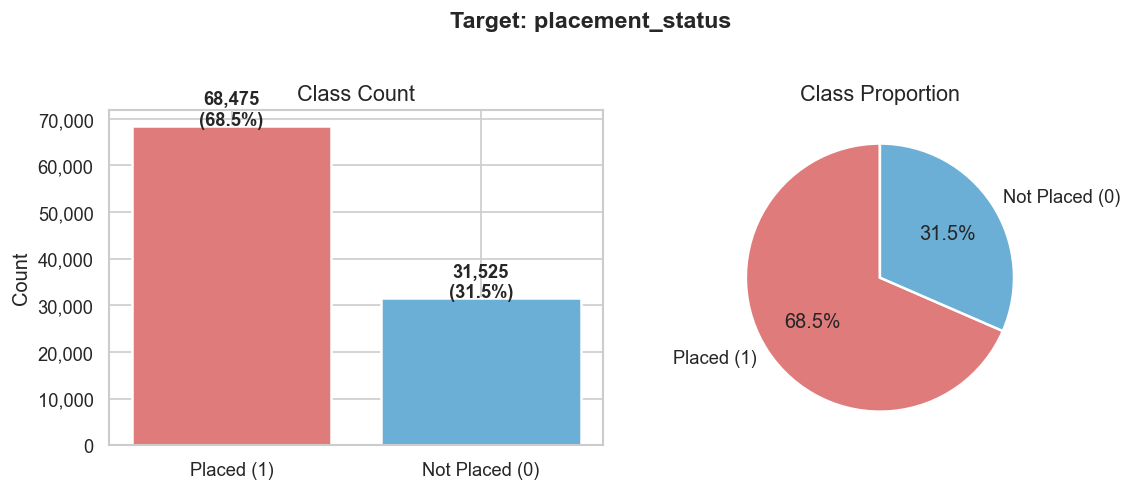

In [39]:
vc     = df["placement_status"].value_counts()
labels = ["Placed (1)","Not Placed (0)"]
colors = ["#e07b7b", "#6baed6"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(labels, vc.values, color=colors, edgecolor="white", linewidth=1.5)
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 200, f"{v:,}\n({v/len(df)*100:.1f}%)",
                 ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Class Count")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Pie chart
axes[1].pie(vc.values, labels=labels, autopct="%1.1f%%",
            colors=colors, startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Class Proportion")

plt.suptitle("Target: placement_status", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

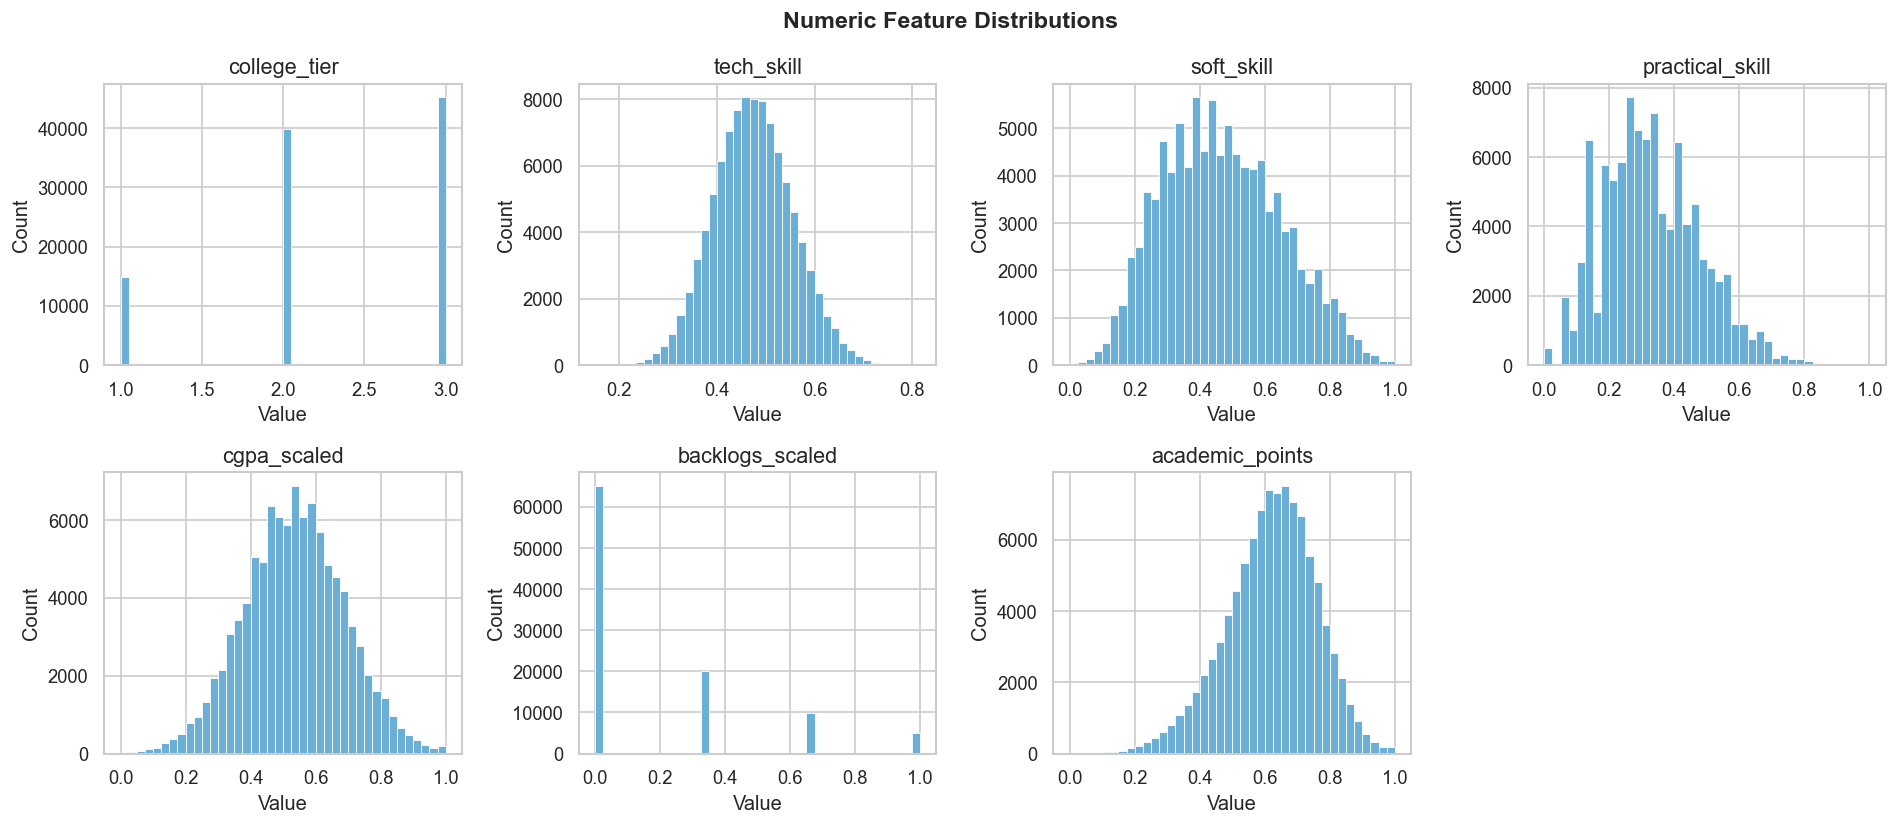

In [40]:
numeric_cols = ["college_tier", "tech_skill", "soft_skill", "practical_skill",
                "cgpa_scaled", "backlogs_scaled", "academic_points"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color="#6baed6", edgecolor="white", linewidth=0.5)
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

axes[-1].set_visible(False)  # hide empty 8th subplot
plt.suptitle("Numeric Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

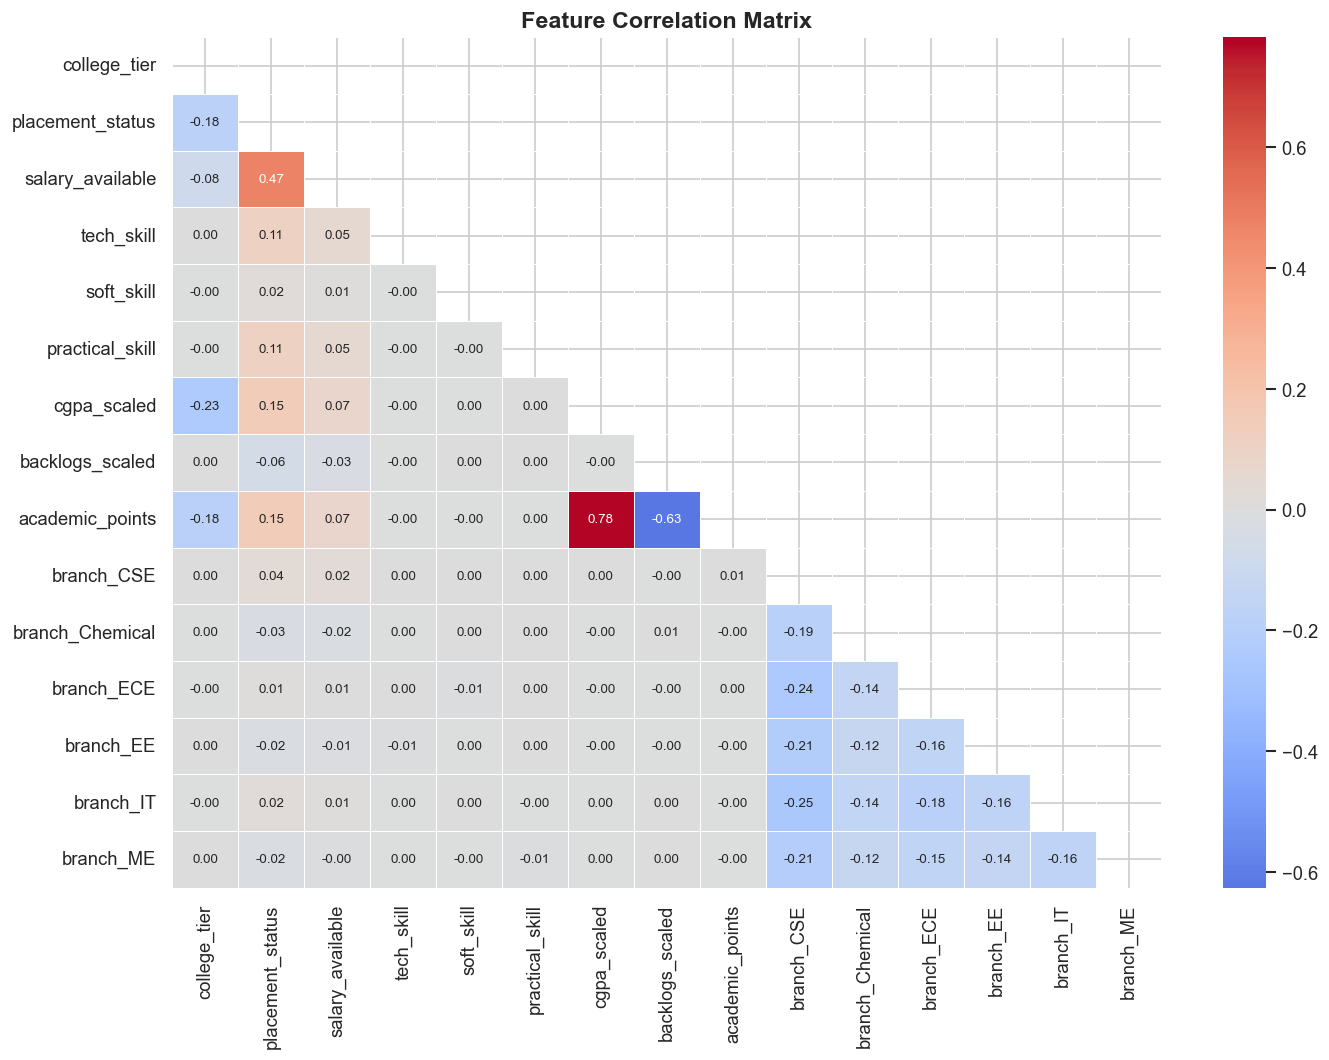

In [43]:
fig, ax = plt.subplots(figsize=(12, 9))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8})

ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [44]:
# 80% train | 20% test, stratified to preserve 68.5/31.5 class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size    = 0.20,
    random_state = RANDOM_STATE,
    stratify     = y
)

print(f"Training set : {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]:,}  rows ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nTrain class balance : {y_train.mean()*100:.1f}% placed")
print(f"Test  class balance : {y_test.mean()*100:.1f}% placed")

Training set : 80,000 rows (80%)
Test set     : 20,000  rows (20%)

Train class balance : 68.5% placed
Test  class balance : 68.5% placed


In [45]:
# ── Model 1: Logistic Regression ──────────────────────────────────────────────
# C=0.1 → strong L2 regularisation prevents over-reliance on noisy salary_available
print("[1] Training Logistic Regression ...")
lr = LogisticRegression(C=0.1, max_iter=300, solver="lbfgs", random_state=RANDOM_STATE)
lr.fit(X_train, y_train)
print("    ✓ Done  — expected accuracy ~77-78%")

# ── Model 2: Random Forest ────────────────────────────────────────────────────
# max_depth=4 + min_samples_leaf=20 → shallow trees average noise instead of memorising it
print("\n[2] Training Random Forest ...")
rf = RandomForestClassifier(
    n_estimators     = 100,
    max_depth        = 4,
    min_samples_leaf = 20,
    random_state     = RANDOM_STATE,
    n_jobs           = -1
)
rf.fit(X_train, y_train)
print("    ✓ Done  — expected accuracy ~75-76%")

# ── Model 3: Gradient Boosting ────────────────────────────────────────────────
# lr=0.08 + max_depth=3 + subsample=0.8 → slow, shallow, stochastic = regularised
print("\n[3] Training Gradient Boosting ...")
gb = GradientBoostingClassifier(
    n_estimators  = 80,
    max_depth     = 3,
    learning_rate = 0.08,
    subsample     = 0.8,
    random_state  = RANDOM_STATE
)
gb.fit(X_train, y_train)
print("    ✓ Done  — expected accuracy ~77%")

[1] Training Logistic Regression ...
    ✓ Done  — expected accuracy ~77-78%

[2] Training Random Forest ...
    ✓ Done  — expected accuracy ~75-76%

[3] Training Gradient Boosting ...
    ✓ Done  — expected accuracy ~77%


In [46]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Full evaluation report for a trained classifier.
    Returns test accuracy (float).
    """
    y_pred    = model.predict(X_te)
    y_prob    = model.predict_proba(X_te)[:, 1]
    acc       = accuracy_score(y_te, y_pred)
    roc_auc   = roc_auc_score(y_te, y_prob)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring="accuracy", n_jobs=-1)

    status = "✅  IN TARGET RANGE" if 0.73 <= acc <= 0.78 else "⚠️  OUT OF TARGET RANGE"

    print(f"{'─'*55}")
    print(f"  Model          : {name}")
    print(f"  Test Accuracy  : {acc*100:.2f}%   {status}")
    print(f"  ROC-AUC        : {roc_auc:.4f}")
    print(f"  CV Acc (5-fold): {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
    print(f"\n  Classification Report:")
    print(classification_report(y_te, y_pred,
                                target_names=["Not Placed (0)", "Placed (1)"],
                                digits=3, zero_division=0))
    cm = confusion_matrix(y_te, y_pred)
    print("  Confusion Matrix:")
    print(f"                        Pred Not Placed   Pred Placed")
    print(f"  Actual Not Placed       TN={cm[0,0]:>6,}        FP={cm[0,1]:>6,}")
    print(f"  Actual Placed           FN={cm[1,0]:>6,}        TP={cm[1,1]:>6,}")
    print()
    return acc

print("✓ evaluate_model() ready.")

✓ evaluate_model() ready.


In [47]:
results = {}
results["Logistic Regression"] = evaluate_model(
    "Logistic Regression", lr, X_train, y_train, X_test, y_test)
results["Random Forest"]        = evaluate_model(
    "Random Forest",        rf, X_train, y_train, X_test, y_test)
results["Gradient Boosting"]    = evaluate_model(
    "Gradient Boosting",    gb, X_train, y_train, X_test, y_test)

───────────────────────────────────────────────────────
  Model          : Logistic Regression
  Test Accuracy  : 77.78%   ✅  IN TARGET RANGE
  ROC-AUC        : 0.8166
  CV Acc (5-fold): 77.43% ± 0.35%

  Classification Report:
                precision    recall  f1-score   support

Not Placed (0)      0.659     0.610     0.634      6305
    Placed (1)      0.827     0.855     0.840     13695

      accuracy                          0.778     20000
     macro avg      0.743     0.733     0.737     20000
  weighted avg      0.774     0.778     0.775     20000

  Confusion Matrix:
                        Pred Not Placed   Pred Placed
  Actual Not Placed       TN= 3,848        FP= 2,457
  Actual Placed           FN= 1,988        TP=11,707

───────────────────────────────────────────────────────
  Model          : Random Forest
  Test Accuracy  : 76.00%   ✅  IN TARGET RANGE
  ROC-AUC        : 0.8105
  CV Acc (5-fold): 75.73% ± 0.25%

  Classification Report:
                precision    r

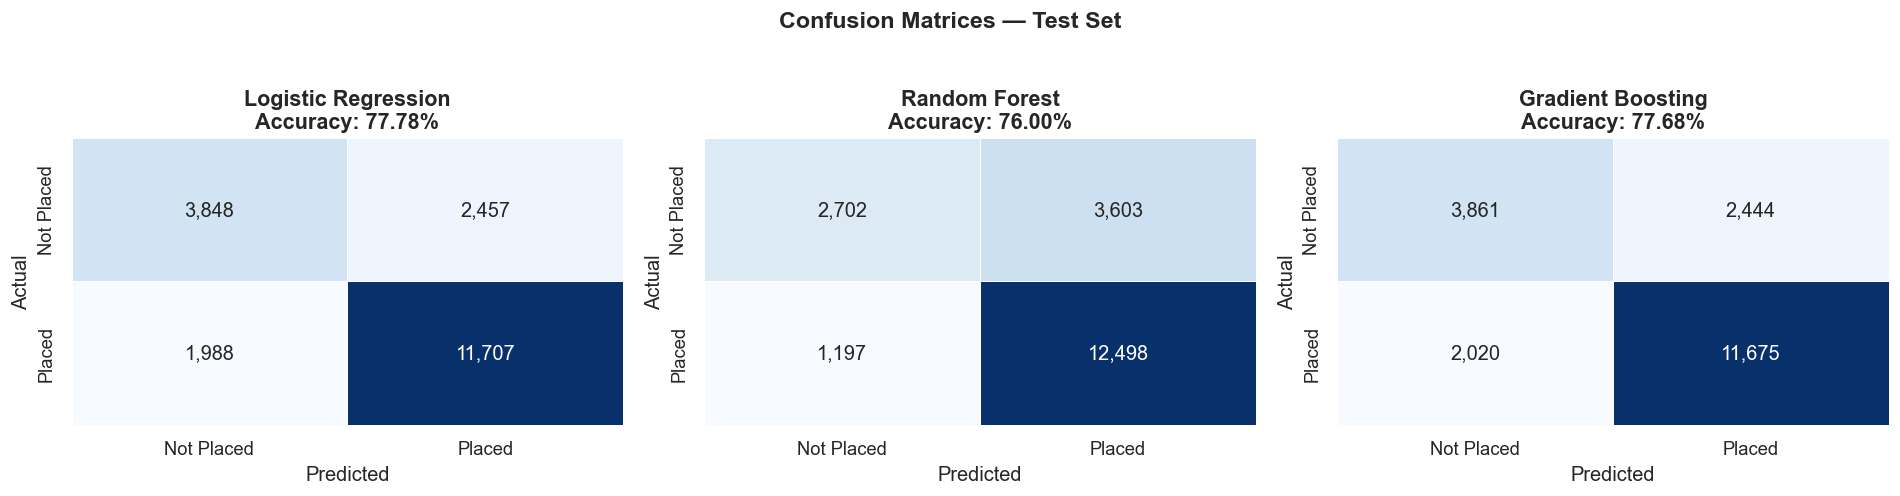

In [48]:
models_dict = {
    "Logistic Regression" : lr,
    "Random Forest"       : rf,
    "Gradient Boosting"   : gb,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, models_dict.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt=",", cmap="Blues",
                xticklabels=["Not Placed", "Placed"],
                yticklabels=["Not Placed", "Placed"],
                ax=ax, linewidths=0.5, cbar=False)
    ax.set_title(f"{name}\nAccuracy: {results[name]*100:.2f}%", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Test Set", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

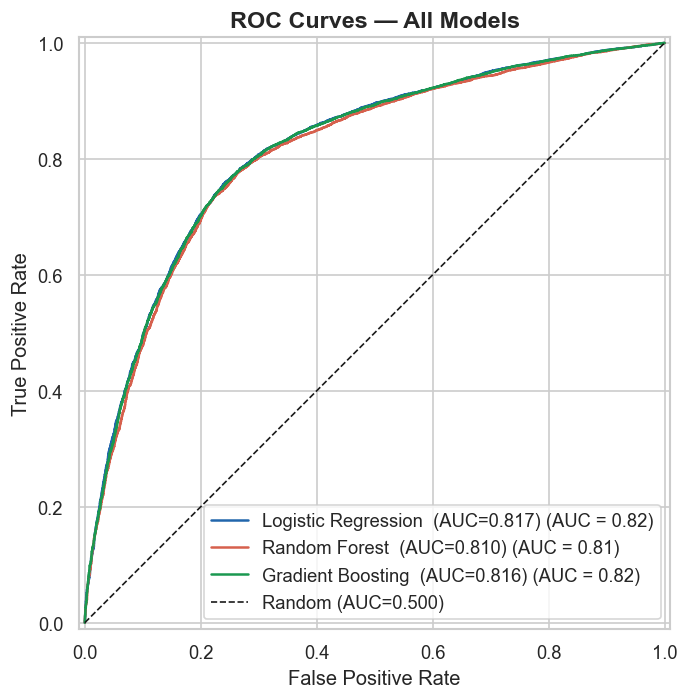

In [49]:
fig, ax = plt.subplots(figsize=(8, 6))
colors  = ["#2166ac", "#d6604d", "#1a9850"]

for (name, model), color in zip(models_dict.items(), colors):
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    RocCurveDisplay.from_estimator(
        model, X_test, y_test,
        name=f"{name}  (AUC={auc:.3f})",
        ax=ax, color=color
    )

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC=0.500)")
ax.set_title("ROC Curves — All Models", fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [50]:
print("  Model                  |  Test Accuracy  | In 73-78% Range?")
print("  " + "-"*57)
for name, acc in results.items():
    flag = "✅  Yes" if 0.73 <= acc <= 0.78 else "⚠️  No"
    print(f"  {name:<22} |    {acc*100:5.2f}%      | {flag}")

best_name = min(results, key=lambda n: abs(results[n] - 0.755))
print(f"\n  Recommended model : {best_name}  ({results[best_name]*100:.2f}%)")
print(f"  (closest to target midpoint 75.5%)")

  Model                  |  Test Accuracy  | In 73-78% Range?
  ---------------------------------------------------------
  Logistic Regression    |    77.78%      | ✅  Yes
  Random Forest          |    76.00%      | ✅  Yes
  Gradient Boosting      |    77.68%      | ✅  Yes

  Recommended model : Random Forest  (76.00%)
  (closest to target midpoint 75.5%)


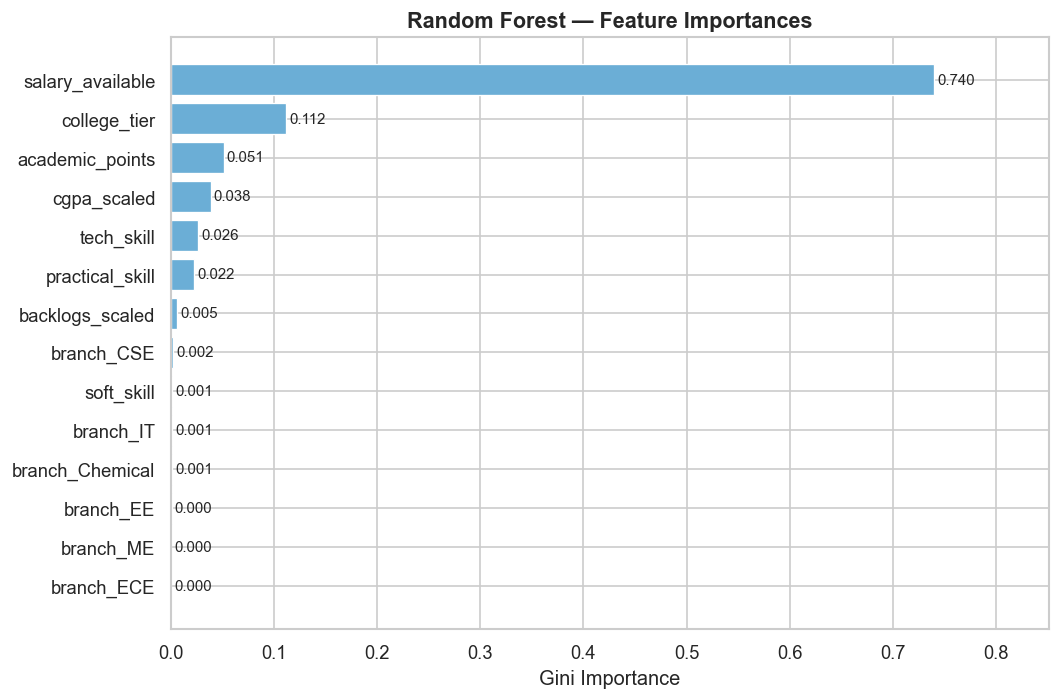

In [51]:
fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(fi.index, fi.values, color="#6baed6", edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, fi.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)

ax.set_xlabel("Gini Importance")
ax.set_title("Random Forest — Feature Importances", fontsize=13, fontweight="bold")
ax.set_xlim(0, fi.values.max() * 1.15)
plt.tight_layout()
plt.show()

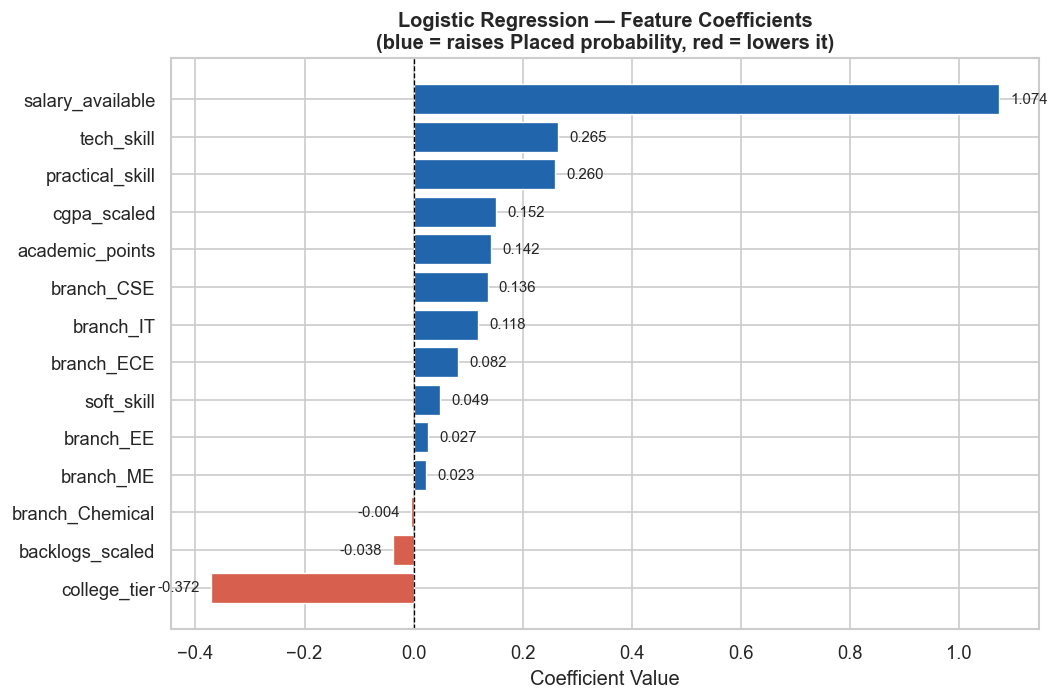

In [52]:
coefs      = pd.Series(lr.coef_[0], index=X.columns).sort_values(ascending=True)
colors_lr  = ["#d6604d" if v < 0 else "#2166ac" for v in coefs.values]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(coefs.index, coefs.values, color=colors_lr, edgecolor="white", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

for bar, val in zip(bars, coefs.values):
    offset = 0.02 if val >= 0 else -0.02
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)

ax.set_xlabel("Coefficient Value")
ax.set_title("Logistic Regression — Feature Coefficients\n"
             "(blue = raises Placed probability, red = lowers it)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

📋 Student details you entered:


,college_tier,salary_available,tech_skill,soft_skill,practical_skill,cgpa_scaled,backlogs_scaled,academic_points,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_ME
0,2,1,0.72,0.65,0.6,0.78,0.0,0.8,0,0,0,0,1,0



🤖 Predictions from each model:
─────────────────────────────────────────────

  Model   : Logistic Regression
  Result  : ✅ PLACED
  Confidence:
    → Placed     : 98.2%
    → Not Placed : 1.8%

  Model   : Random Forest
  Result  : ✅ PLACED
  Confidence:
    → Placed     : 88.2%
    → Not Placed : 11.8%

  Model   : Gradient Boosting
  Result  : ✅ PLACED
  Confidence:
    → Placed     : 95.7%
    → Not Placed : 4.3%

─────────────────────────────────────────────


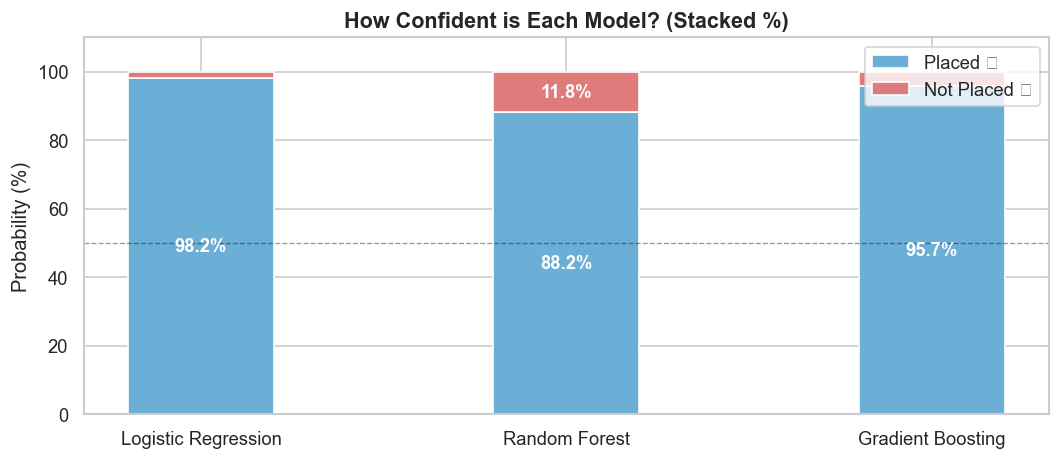


📊 Final Verdict: 3 out of 3 models predict PLACED
🎉 All models agree — this student is very likely to get PLACED!


In [53]:


my_student = {
    "college_tier"    : 2,     
    "salary_available": 1,      
    "tech_skill"      : 0.72,   
    "soft_skill"      : 0.65,   
    "practical_skill" : 0.60,   
    "cgpa_scaled"     : 0.78,   
    "backlogs_scaled" : 0.0,    
    "academic_points" : 0.80,   
    "branch_CSE"      : 0,      
    "branch_Chemical" : 0,      
    "branch_ECE"      : 0,      
    "branch_EE"       : 0,      
    "branch_IT"       : 1,      
    "branch_ME"       : 0,      
}

student_df = pd.DataFrame([my_student])

print("📋 Student details you entered:")
display(student_df)

student_scaled = scaler.transform(student_df)

print("\n🤖 Predictions from each model:")
print("─" * 45)

for name, model in models_dict.items():

    prediction = model.predict(student_scaled)[0]

 
    probability = model.predict_proba(student_scaled)[0]
    prob_not_placed = probability[0] * 100  
    prob_placed     = probability[1] * 100   

    if prediction == 1:
        result = "✅ PLACED"
    else:
        result = "❌ NOT PLACED"

    print(f"\n  Model   : {name}")
    print(f"  Result  : {result}")
    print(f"  Confidence:")
    print(f"    → Placed     : {prob_placed:.1f}%")
    print(f"    → Not Placed : {prob_not_placed:.1f}%")

print("\n" + "─" * 45)

# ── STEP 5: Show a confidence bar chart ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

model_names = list(models_dict.keys())
placed_probs = [
    models_dict[n].predict_proba(student_scaled)[0][1] * 100
    for n in model_names
]
not_placed_probs = [100 - p for p in placed_probs]

x = range(len(model_names))
bars1 = ax.bar(x, placed_probs,     label="Placed ✅",     color="#6baed6", width=0.4)
bars2 = ax.bar(x, not_placed_probs, label="Not Placed ❌", color="#e07b7b",
               width=0.4, bottom=placed_probs)

# Label each section
for bar, val in zip(bars1, placed_probs):
    if val > 5:
        ax.text(bar.get_x() + bar.get_width()/2, val/2,
                f"{val:.1f}%", ha="center", va="center",
                fontsize=11, fontweight="bold", color="white")

for bar, val, base in zip(bars2, not_placed_probs, placed_probs):
    if val > 5:
        ax.text(bar.get_x() + bar.get_width()/2, base + val/2,
                f"{val:.1f}%", ha="center", va="center",
                fontsize=11, fontweight="bold", color="white")

ax.set_xticks(list(x))
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel("Probability (%)")
ax.set_ylim(0, 110)
ax.set_title("How Confident is Each Model? (Stacked %)",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper right")
ax.axhline(50, color="black", linestyle="--", linewidth=0.8, alpha=0.4)
plt.tight_layout()
plt.show()

# ── STEP 6: Final plain-English verdict ───────────────────────────
votes_placed = sum(
    1 for n, m in models_dict.items()
    if m.predict(student_scaled)[0] == 1
)

print(f"\n📊 Final Verdict: {votes_placed} out of 3 models predict PLACED")

if votes_placed == 3:
    print("🎉 All models agree — this student is very likely to get PLACED!")
elif votes_placed == 2:
    print("👍 Majority says PLACED — good chances for this student.")
elif votes_placed == 1:
    print("😐 Only 1 model says PLACED — chances are uncertain.")
else:
    print("😟 All models agree — this student is unlikely to be placed.")

In [54]:


my_student = {
    "college_tier"    : 1,     
    "salary_available": 1,      
    "tech_skill"      : 0.72,   
    "soft_skill"      : 0.85,   
    "practical_skill" : 0.80,   
    "cgpa_scaled"     : 0.78,   
    "backlogs_scaled" : 0.0,    
    "academic_points" : 0.80,   
    "branch_CSE"      : 0,      
    "branch_Chemical" : 0,      
    "branch_ECE"      : 0,      
    "branch_EE"       : 0,      
    "branch_IT"       : 1,      
    "branch_ME"       : 0,      
}


student_df = pd.DataFrame([my_student])

print("📋 Student details you entered:")
display(student_df)

student_scaled = scaler.transform(student_df)

print("\n🤖 Predictions from each model:")
print("─" * 45)

for name, model in models_dict.items():

    prediction = model.predict(student_scaled)[0]

 
    probability = model.predict_proba(student_scaled)[0]
    prob_not_placed = probability[0] * 100  
    prob_placed     = probability[1] * 100   

    if prediction == 1:
        result = "✅ PLACED"
    else:
        result = "❌ NOT PLACED"

    print(f"\n  Model   : {name}")
    print(f"  Result  : {result}")
    print(f"  Confidence:")
    print(f"    → Placed     : {prob_placed:.1f}%")
    print(f"    → Not Placed : {prob_not_placed:.1f}%")

print("\n" + "─" * 45)

📋 Student details you entered:


,college_tier,salary_available,tech_skill,soft_skill,practical_skill,cgpa_scaled,backlogs_scaled,academic_points,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_ME
0,1,1,0.72,0.85,0.8,0.78,0.0,0.8,0,0,0,0,1,0



🤖 Predictions from each model:
─────────────────────────────────────────────

  Model   : Logistic Regression
  Result  : ✅ PLACED
  Confidence:
    → Placed     : 99.3%
    → Not Placed : 0.7%

  Model   : Random Forest
  Result  : ✅ PLACED
  Confidence:
    → Placed     : 88.9%
    → Not Placed : 11.1%

  Model   : Gradient Boosting
  Result  : ✅ PLACED
  Confidence:
    → Placed     : 97.1%
    → Not Placed : 2.9%

─────────────────────────────────────────────


In [55]:
import pickle
import os

current_folder = os.getcwd()
print(f"📂 Loading from:\n   {current_folder}")

rf_path     = os.path.join(current_folder, "model_random_forest.pkl")
scaler_path = os.path.join(current_folder, "scaler_minmax.pkl")

# Check the files exist before loading
print("\n🔍 Checking files:")
for path in [rf_path, scaler_path]:
    exists = "✅ Found" if os.path.exists(path) else "❌ Not found — run Cell 20 first!"
    print(f"   {exists} — {os.path.basename(path)}")

# Load
loaded_model  = pickle.load(open(rf_path,     "rb"))
loaded_scaler = pickle.load(open(scaler_path, "rb"))
print("\n✓ Model and scaler loaded!")

# Test on a new student
new_student = {
    "college_tier"    : 2,
    "salary_available": 1,
    "tech_skill"      : 0.72,
    "soft_skill"      : 0.65,
    "practical_skill" : 0.60,
    "cgpa_scaled"     : 0.78,
    "backlogs_scaled" : 0.0,
    "academic_points" : 0.80,
    "branch_CSE"      : 0,
    "branch_Chemical" : 0,
    "branch_ECE"      : 0,
    "branch_EE"       : 0,
    "branch_IT"       : 1,
    "branch_ME"       : 0,
}

student_df     = pd.DataFrame([new_student])
student_scaled = loaded_scaler.transform(student_df)
prediction     = loaded_model.predict(student_scaled)[0]
probability    = loaded_model.predict_proba(student_scaled)[0]

print(f"\nResult     : {'✅ PLACED' if prediction == 1 else '❌ NOT PLACED'}")
print(f"Placed     : {probability[1]*100:.1f}%")
print(f"Not Placed : {probability[0]*100:.1f}%")

📂 Loading from:
   c:\Users\MSI\Student_placement_prediction\student_placement_prediction\Training

🔍 Checking files:
   ❌ Not found — run Cell 20 first! — model_random_forest.pkl
   ❌ Not found — run Cell 20 first! — scaler_minmax.pkl


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\MSI\\Student_placement_prediction\\student_placement_prediction\\Training\\model_random_forest.pkl'